In [88]:
from polygon import RESTClient
import pandas as pd
import numpy as np
import sklearn
import scipy
import matplotlib.pyplot as plt
import collections

import datetime

from tqdm import tqdm

from constants import api_key

import time

client = RESTClient(api_key = api_key)

import pyspark

import polars as pl

import seaborn as sns

In [2]:
ticker_hist_pl = pl.scan_parquet('./returns_data_2022_10_15_2024_10_14.parquet/*.parquet')

start_time = "09:30:00"
end_time = "16:00:00"

ticker_hist_pl = ticker_hist_pl.filter(
    (pl.col('Time')>=start_time) & (pl.col('Time')<=end_time)
)

train = ticker_hist_pl.filter(pl.col("Date")<datetime.date(2024, 7, 1))
test = ticker_hist_pl.filter(pl.col("Date")>=datetime.date(2024, 7, 1))


In [3]:
tickers = pd.read_html(
    'https://en.wikipedia.org/wiki/List_of_S%26P_500_companies')[0]
print(tickers.head())

  Symbol             Security             GICS Sector  \
0    MMM                   3M             Industrials   
1    AOS          A. O. Smith             Industrials   
2    ABT  Abbott Laboratories             Health Care   
3   ABBV               AbbVie             Health Care   
4    ACN            Accenture  Information Technology   

                GICS Sub-Industry    Headquarters Location  Date added  \
0        Industrial Conglomerates    Saint Paul, Minnesota  1957-03-04   
1               Building Products     Milwaukee, Wisconsin  2017-07-26   
2           Health Care Equipment  North Chicago, Illinois  1957-03-04   
3                   Biotechnology  North Chicago, Illinois  2012-12-31   
4  IT Consulting & Other Services          Dublin, Ireland  2011-07-06   

       CIK      Founded  
0    66740         1902  
1    91142         1916  
2     1800         1888  
3  1551152  2013 (1888)  
4  1467373         1989  


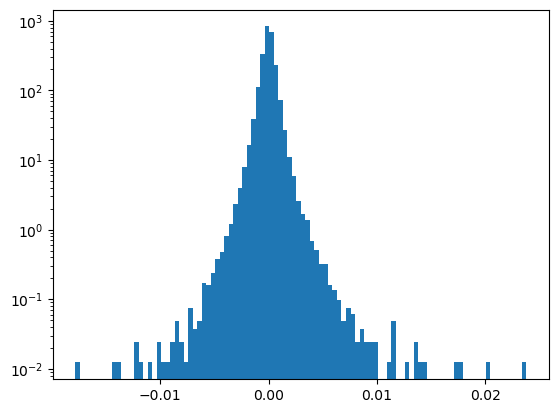

In [4]:
plt.hist(ticker_hist_pl.filter(pl.col('ticker')=='MMM').select(pl.col('logReturns')).collect(), bins = 100, density = True)
plt.yscale('log')

In [5]:
ticker_hist_date

NameError: name 'ticker_hist_date' is not defined

In [8]:
all_tickers = list(tickers['Symbol'].values) + ['VIXY']

a_params_train = {}
b_params_train = {}
finished_up_train = {}

a_params_test = {}
b_params_test = {}
finished_up_test = {}



for ticker in tqdm(all_tickers):
    a_params_train[ticker] = {}
    b_params_train[ticker] = {}
    finished_up_train[ticker] = {}

    ticker_specific_hist = train.filter(pl.col("ticker") == ticker).collect()

    dates = list(ticker_specific_hist.select("Date").unique())[0]
    
    if ticker_specific_hist.height > 0:  # Equivalent to len() in Pandas
        for date in dates:
            # Filter the DataFrame for the specific date
            ticker_hist_date = ticker_specific_hist.filter(pl.col('Date') == date)
            ticker_hist_date = ticker_hist_date.to_pandas()
            
            if len(ticker_hist_date)>0:
                ticker_hist_date = ticker_hist_date.sort_values('logReturns').reset_index(drop = True)
                ticker_hist_date.loc[:, 'cumulative_volume'] = ticker_hist_date['volume'].cumsum()/ticker_hist_date['volume'].sum()
        
                a_param = ticker_hist_date[ticker_hist_date['cumulative_volume']>=0.5]['logReturns'].iloc[0]
                mae = np.sum(abs(a_param - ticker_hist_date['logReturns'])*ticker_hist_date['volume'])/ticker_hist_date['volume'].sum()
                
                a_params_train[ticker][date] = a_param
                b_params_train[ticker][date] = mae
                finished_up_train[ticker][date] = ticker_hist_date['logReturns'].sum()

for ticker in tqdm(all_tickers):
    a_params_test[ticker] = {}
    b_params_test[ticker] = {}
    finished_up_test[ticker] = {}

    ticker_specific_hist = test.filter(pl.col("ticker") == ticker).collect()

    dates = list(ticker_specific_hist.select("Date").unique())[0]
    
    if ticker_specific_hist.height > 0:  # Equivalent to len() in Pandas
        for date in dates:
            # Filter the DataFrame for the specific date
            ticker_hist_date = ticker_specific_hist.filter(pl.col('Date') == date)
            ticker_hist_date = ticker_hist_date.to_pandas()
            
            if len(ticker_hist_date)>0:
                ticker_hist_date = ticker_hist_date.sort_values('logReturns').reset_index(drop = True)
                ticker_hist_date.loc[:, 'cumulative_volume'] = ticker_hist_date['volume'].cumsum()/ticker_hist_date['volume'].sum()
        
                a_param = ticker_hist_date[ticker_hist_date['cumulative_volume']>=0.5]['logReturns'].iloc[0]
                mae = np.sum(abs(a_param - ticker_hist_date['logReturns'])*ticker_hist_date['volume'])/ticker_hist_date['volume'].sum()
                
                a_params_test[ticker][date] = a_param
                b_params_test[ticker][date] = mae
                finished_up_test[ticker][date] = ticker_hist_date['logReturns'].sum()

100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 504/504 [01:42<00:00,  4.92it/s]


In [7]:
ticker_hist_pl.collect()

Open,Close,high,low,volume,Datetime,transactions,ticker,Date,Time,logOpen,logClose,logReturns
f64,f64,f64,f64,f64,datetime[ns],i64,str,date,str,f64,f64,f64
84.1,83.9,84.2,83.9,33806.4,2022-10-17 13:30:00,575,"""VIXY""",2022-10-17,"""09:30:00""",4.432007,4.429626,-0.002381
83.925,83.75,83.9435,83.75,14003.8,2022-10-17 13:31:00,336,"""VIXY""",2022-10-17,"""09:31:00""",4.429924,4.427836,-0.002087
83.75,83.85,83.875,83.65,25108.8,2022-10-17 13:32:00,428,"""VIXY""",2022-10-17,"""09:32:00""",4.427836,4.429029,0.001193
83.85,83.983,84.0,83.8,9935.6,2022-10-17 13:33:00,188,"""VIXY""",2022-10-17,"""09:33:00""",4.429029,4.430614,0.001585
84.0,83.9395,84.0,83.825,4864.0,2022-10-17 13:34:00,78,"""VIXY""",2022-10-17,"""09:34:00""",4.430817,4.430096,-0.00072
…,…,…,…,…,…,…,…,…,…,…,…,…
192.91,192.96,193.0,192.855,11103.0,2024-10-14 19:56:00,278,"""ZTS""",2024-10-14,"""15:56:00""",5.262224,5.262483,0.000259
193.0,192.91,193.01,192.89,11154.0,2024-10-14 19:57:00,259,"""ZTS""",2024-10-14,"""15:57:00""",5.26269,5.262224,-0.000466
192.88,192.75,192.93,192.75,23855.0,2024-10-14 19:58:00,561,"""ZTS""",2024-10-14,"""15:58:00""",5.262068,5.261394,-0.000674


In [8]:
ticker_hist_date.sort_values('Time')

,Open,Close,high,low,volume,Datetime,transactions,ticker,Date,Time,logOpen,logClose,logReturns,cumulative_volume
140,13.1600,13.1600,13.1900,13.1600,36704.0,2024-10-14 13:30:00,75,VIXY,2024-10-14,09:30:00,2.577182,2.577182,0.000000,0.505921
274,13.1600,13.1650,13.1650,13.1600,2200.0,2024-10-14 13:31:00,3,VIXY,2024-10-14,09:31:00,2.577182,2.577562,0.000380,0.728375
310,13.1600,13.1675,13.1675,13.1600,1612.0,2024-10-14 13:32:00,11,VIXY,2024-10-14,09:32:00,2.577182,2.577752,0.000570,0.793612
348,13.1600,13.1900,13.1900,13.1600,7965.0,2024-10-14 13:33:00,62,VIXY,2024-10-14,09:33:00,2.577182,2.579459,0.002277,0.985302
273,13.1700,13.1750,13.1750,13.1700,1696.0,2024-10-14 13:34:00,15,VIXY,2024-10-14,09:34:00,2.577942,2.578321,0.000380,0.727582
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
18,12.8801,12.8650,12.8850,12.8650,16842.0,2024-10-14 19:56:00,82,VIXY,2024-10-14,15:56:00,2.555683,2.554510,-0.001173,0.137625
336,12.8700,12.8809,12.8900,12.8700,15680.0,2024-10-14 19:57:00,54,VIXY,2024-10-14,15:57:00,2.554899,2.555746,0.000847,0.933093
289,12.8850,12.8900,12.8900,12.8813,8691.0,2024-10-14 19:58:00,36,VIXY,2024-10-14,15:58:00,2.556064,2.556452,0.000388,0.758966
224,12.8850,12.8850,12.8900,12.8600,132667.0,2024-10-14 19:59:00,488,VIXY,2024-10-14,15:59:00,2.556064,2.556064,0.000000,0.638773


In [9]:
a_params_train_df = pd.DataFrame(a_params_train).sort_index().dropna(axis=1)
a_params_test_df = pd.DataFrame(a_params_test).sort_index()[a_params_train_df.columns]
finished_up_train_df = pd.DataFrame(finished_up_train).sort_index()[a_params_train_df.columns]

b_params_train_df = pd.DataFrame(b_params_train).sort_index()[a_params_train_df.columns]
b_params_test_df = pd.DataFrame(b_params_test).sort_index()[a_params_train_df.columns]
finished_up_test_df = pd.DataFrame(finished_up_test).sort_index()[a_params_train_df.columns]

In [10]:
scipy.stats.spearmanr(a_params_train_df.values.flatten(), finished_up_train_df.values.flatten())

SignificanceResult(statistic=np.float64(0.48055920255951673), pvalue=np.float64(0.0))

In [11]:
a_params_train_df.shape

(427, 485)

In [12]:
a_params_test_df.shape

(74, 485)

In [13]:
b_params_train_df.shape

(427, 485)

In [14]:
b_params_test_df.shape

(74, 485)

In [15]:
log_b_params_train_df = np.log(b_params_train_df)
log_b_params_test_df = np.log(b_params_test_df)

In [18]:
from sklearn.preprocessing import RobustScaler, StandardScaler

rs_scaler = RobustScaler()

scaled_values = rs_scaler.fit_transform(a_params_train_df.values)

scaled_a_train_df = pd.DataFrame(scaled_values, index = a_params_train_df.index, columns=a_params_train_df.columns)
scaled_a_train_df

scaled_values = rs_scaler.transform(a_params_test_df.values)

scaled_a_test_df = pd.DataFrame(scaled_values, index = a_params_test_df.index, columns=a_params_test_df.columns)
scaled_a_test_df

,MMM,AOS,ABT,ABBV,ACN,ADBE,AMD,AES,AFL,A,...,WMB,WTW,WYNN,XEL,XYL,YUM,ZBRA,ZBH,ZTS,VIXY
2024-07-01,-1.084180,0.000000,0.000000,0.000000,0.679212,0.000000,-0.936239,0.0,-0.000112,-2.666347,...,0.000000,0.000000,0.000000,-0.000023,-1.966759,-1.493625,0.0,-2.378427,-0.667575,0.00000
2024-07-02,0.000000,0.000000,1.394145,0.000000,0.677885,0.236302,1.700781,0.0,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,-1.191772,1.653732,0.00000
2024-07-03,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-0.046882,0.0,0.000000,-1.806913,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.00000
2024-07-05,-0.032398,0.000000,3.186660,0.753591,-2.395091,-0.116267,0.774899,0.0,0.000000,0.000000,...,0.000000,0.000000,-1.083922,0.000000,0.981420,0.000000,0.0,0.000000,-1.313956,0.00001
2024-07-08,0.000000,0.000062,0.000000,0.743835,-0.343741,0.000000,1.318972,0.0,-0.000113,0.000000,...,-0.000118,0.000000,-1.317449,-0.000002,0.000000,0.000000,0.0,0.000000,0.000000,0.00000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-10-08,0.000000,0.000000,0.000000,0.000000,-0.284458,-0.541473,0.425097,0.0,0.000000,0.000000,...,0.000000,0.000000,-1.839497,0.000000,0.000000,-1.913515,0.0,-2.471730,0.000000,0.00000
2024-10-09,0.404773,0.000000,0.000000,0.000000,0.282442,-0.408259,-1.270738,0.0,0.000000,0.000000,...,0.000000,0.000101,1.796888,-0.000080,0.000000,-0.957662,0.0,0.000000,0.302995,0.00000
2024-10-10,-0.408337,0.000000,-2.816364,0.000000,0.000000,0.398656,-0.796424,0.0,0.000000,-0.796836,...,0.000000,0.000000,-1.795513,-0.000080,-0.383791,-1.936902,0.0,0.000000,0.000000,0.00000
2024-10-11,-0.268800,-0.000031,0.000000,-0.318906,1.134169,-1.352047,0.785939,0.0,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.960797,0.0,1.202003,0.000000,0.00000


In [19]:
rs_scaler = StandardScaler()

scaled_values = rs_scaler.fit_transform(log_b_params_train_df.values)

scaled_b_train_df = pd.DataFrame(scaled_values, index = b_params_train_df.index, columns=b_params_train_df.columns)
scaled_b_train_df

scaled_values = rs_scaler.transform(log_b_params_test_df.values)

scaled_b_test_df = pd.DataFrame(scaled_values, index = b_params_test_df.index, columns=b_params_test_df.columns)
scaled_b_test_df

,MMM,AOS,ABT,ABBV,ACN,ADBE,AMD,AES,AFL,A,...,WMB,WTW,WYNN,XEL,XYL,YUM,ZBRA,ZBH,ZTS,VIXY
2024-07-01,-0.122319,-0.242241,0.026082,0.889391,-0.160678,-0.116275,0.853583,1.078895,0.611745,0.397452,...,-1.498860,-0.005748,-0.852292,-0.575221,1.208727,-0.394564,-0.214345,1.352270,0.743729,-1.104189
2024-07-02,-1.335975,-0.144008,-1.210278,-0.446741,0.227486,-0.229092,0.244232,0.581067,-0.459149,-1.024031,...,-1.200368,-1.189456,-0.553386,-1.121291,0.720384,-0.421441,0.012189,-0.656604,0.352117,-2.034906
2024-07-03,0.091196,-0.231921,-0.285278,0.235091,-1.440681,0.727883,0.389491,-0.650327,-0.544823,-0.156520,...,-1.033249,-0.949445,0.256223,-0.592208,-1.204219,-0.765518,0.191891,-0.352692,0.817953,-0.683701
2024-07-05,-0.292792,0.202134,0.302349,0.040178,1.050068,-1.245034,0.933686,0.175035,-1.426939,-0.246259,...,-1.020341,-0.416891,-0.816554,-0.706919,-1.004509,-1.287827,-1.467295,-1.037242,0.468714,0.353347
2024-07-08,-0.394571,-0.450627,-0.893345,-0.098839,-1.131859,0.159201,1.165815,-0.926228,0.062259,-1.835039,...,-1.667331,-0.542850,-1.091167,-0.522958,-1.310406,0.145918,-1.034468,-0.235391,-1.182497,-1.368486
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-10-08,-0.897530,-0.513100,2.348167,-1.329577,-0.932079,1.497736,-0.613774,-0.085976,-0.296860,0.205792,...,0.144608,-0.444800,1.706793,-0.356830,-0.116257,-0.006281,-1.305576,-1.058404,0.601130,0.056985
2024-10-09,-1.017898,-1.506167,-0.817067,-0.803790,-0.783393,-2.238859,-0.596041,-0.667470,-0.046210,-0.723380,...,0.276001,-0.036278,-0.446215,-1.200812,-0.646952,-0.353939,-1.624374,-0.741185,-1.309055,-0.571985
2024-10-10,-0.699893,-1.423342,-0.434897,-0.134486,0.532619,-0.949650,0.503504,0.039411,-0.239284,-0.848093,...,-0.308936,0.419824,-0.160434,-0.766560,-0.806361,1.237641,0.392444,-0.927189,-0.797874,-0.026272
2024-10-11,-1.426917,3.577415,-0.724214,-1.349093,-1.024416,-1.274849,-1.086044,-0.490663,-1.415880,-0.276943,...,-0.376598,1.032723,-0.152561,-2.418970,-0.682884,-0.251517,-0.924921,-1.030166,-1.068592,-0.807688


In [20]:
one_shifted = scaled_a_train_df.shift(-1)
one_shifted.columns = [f'{col_name}_shift1' for col_name in scaled_a_train_df.columns]
one_shifted = pd.DataFrame(one_shifted.values.flatten())

two_shifted = scaled_a_train_df.shift(-2)
two_shifted.columns = [f'{col_name}_shift2' for col_name in scaled_a_train_df.columns]
two_shifted = pd.DataFrame(two_shifted.values.flatten())

three_shifted = scaled_a_train_df.shift(-3)
three_shifted.columns = [f'{col_name}_shift3' for col_name in scaled_a_train_df.columns]
three_shifted = pd.DataFrame(three_shifted.values.flatten())

four_shifted = scaled_a_train_df.shift(-4)
four_shifted.columns = [f'{col_name}_shift4' for col_name in scaled_a_train_df.columns]
four_shifted = pd.DataFrame(four_shifted.values.flatten())

five_shifted = scaled_a_train_df.shift(-5)
five_shifted.columns = [f'{col_name}_shift5' for col_name in scaled_a_train_df.columns]
five_shifted = pd.DataFrame(five_shifted.values.flatten())

collapsed_df = pd.DataFrame(scaled_a_train_df.values.flatten())

train_a = pd.concat([collapsed_df, one_shifted, two_shifted, three_shifted, four_shifted, five_shifted], axis=1)



one_shifted = scaled_a_test_df.shift(-1)
one_shifted.columns = [f'{col_name}_shift1' for col_name in scaled_a_test_df.columns]
one_shifted = pd.DataFrame(one_shifted.values.flatten())

two_shifted = scaled_a_test_df.shift(-2)
two_shifted.columns = [f'{col_name}_shift2' for col_name in scaled_a_test_df.columns]
two_shifted = pd.DataFrame(two_shifted.values.flatten())

three_shifted = scaled_a_test_df.shift(-3)
three_shifted.columns = [f'{col_name}_shift3' for col_name in scaled_a_test_df.columns]
three_shifted = pd.DataFrame(three_shifted.values.flatten())

four_shifted = scaled_a_test_df.shift(-4)
four_shifted.columns = [f'{col_name}_shift4' for col_name in scaled_a_test_df.columns]
four_shifted = pd.DataFrame(four_shifted.values.flatten())

five_shifted = scaled_a_test_df.shift(-5)
five_shifted.columns = [f'{col_name}_shift5' for col_name in scaled_a_test_df.columns]
five_shifted = pd.DataFrame(five_shifted.values.flatten())

collapsed_df = pd.DataFrame(scaled_a_test_df.values.flatten())

test_a = pd.concat([collapsed_df, one_shifted, two_shifted, three_shifted, four_shifted, five_shifted], axis=1)

In [21]:
one_shifted = scaled_b_train_df.shift(-1)
one_shifted.columns = [f'{col_name}_shift1' for col_name in scaled_b_train_df.columns]
one_shifted = pd.DataFrame(one_shifted.values.flatten())

two_shifted = scaled_b_train_df.shift(-2)
two_shifted.columns = [f'{col_name}_shift2' for col_name in scaled_b_train_df.columns]
two_shifted = pd.DataFrame(two_shifted.values.flatten())

three_shifted = scaled_b_train_df.shift(-3)
three_shifted.columns = [f'{col_name}_shift3' for col_name in scaled_b_train_df.columns]
three_shifted = pd.DataFrame(three_shifted.values.flatten())

four_shifted = scaled_b_train_df.shift(-4)
four_shifted.columns = [f'{col_name}_shift4' for col_name in scaled_b_train_df.columns]
four_shifted = pd.DataFrame(four_shifted.values.flatten())

five_shifted = scaled_b_train_df.shift(-5)
five_shifted.columns = [f'{col_name}_shift5' for col_name in scaled_b_train_df.columns]
five_shifted = pd.DataFrame(five_shifted.values.flatten())

collapsed_df = pd.DataFrame(scaled_b_train_df.values.flatten())

train_b = pd.concat([collapsed_df, one_shifted, two_shifted, three_shifted, four_shifted, five_shifted], axis=1)



one_shifted = scaled_b_test_df.shift(-1)
one_shifted.columns = [f'{col_name}_shift1' for col_name in scaled_b_test_df.columns]
one_shifted = pd.DataFrame(one_shifted.values.flatten())

two_shifted = scaled_b_test_df.shift(-2)
two_shifted.columns = [f'{col_name}_shift2' for col_name in scaled_b_test_df.columns]
two_shifted = pd.DataFrame(two_shifted.values.flatten())

three_shifted = scaled_b_test_df.shift(-3)
three_shifted.columns = [f'{col_name}_shift3' for col_name in scaled_b_test_df.columns]
three_shifted = pd.DataFrame(three_shifted.values.flatten())

four_shifted = scaled_b_test_df.shift(-4)
four_shifted.columns = [f'{col_name}_shift4' for col_name in scaled_b_test_df.columns]
four_shifted = pd.DataFrame(four_shifted.values.flatten())

five_shifted = scaled_b_test_df.shift(-5)
five_shifted.columns = [f'{col_name}_shift5' for col_name in scaled_b_test_df.columns]
five_shifted = pd.DataFrame(five_shifted.values.flatten())

collapsed_df = pd.DataFrame(scaled_b_test_df.values.flatten())

test_b = pd.concat([collapsed_df, one_shifted, two_shifted, three_shifted, four_shifted, five_shifted], axis=1)

In [22]:
train_a.columns = [f'{i}_shift_a' for i in range(6)]
test_a.columns = [f'{i}_shift_a' for i in range(6)]

train_b.columns = [f'{i}_shift_b' for i in range(6)]
test_b.columns = [f'{i}_shift_b' for i in range(6)]



In [23]:
train_ab = pd.concat([train_a, train_b], axis=1)
test_ab = pd.concat([test_a, test_b], axis=1)

In [24]:
finished_up_train_df.shift(-5).values.flatten()

array([0.00522805, 0.00040898, 0.01718645, ...,        nan,        nan,
              nan])

In [25]:
scipy.stats.spearmanr(train_ab.dropna()['0_shift_b'], train_ab.dropna()['1_shift_b'])

SignificanceResult(statistic=np.float64(0.42755051328258664), pvalue=np.float64(0.0))

In [26]:
train_ab

,0_shift_a,1_shift_a,2_shift_a,3_shift_a,4_shift_a,5_shift_a,0_shift_b,1_shift_b,2_shift_b,3_shift_b,4_shift_b,5_shift_b
0,0.000000,0.949676,0.939348,-0.472769,1.500732,0.463432,0.262276,0.079888,-0.290519,0.049397,0.601353,0.585449
1,0.000000,0.000000,0.000099,0.000000,0.000199,0.000000,0.931784,1.343420,0.971111,1.108374,1.448103,1.813140
2,0.000000,0.000000,-1.672254,0.000000,-3.439318,1.672340,0.872563,1.395431,2.924756,1.823549,2.180064,0.835747
3,0.859194,0.859075,0.823361,0.870464,1.998595,1.643623,-0.276092,0.796121,0.254532,-0.127383,0.509480,1.320913
4,1.953435,0.000000,0.000000,0.000000,-1.544177,0.370463,-0.063920,1.169182,0.086951,1.063928,1.318426,1.131359
...,...,...,...,...,...,...,...,...,...,...,...,...
207090,0.000000,NaN,NaN,NaN,NaN,NaN,0.720217,NaN,NaN,NaN,NaN,NaN
207091,0.000000,NaN,NaN,NaN,NaN,NaN,-0.429441,NaN,NaN,NaN,NaN,NaN
207092,0.000000,NaN,NaN,NaN,NaN,NaN,0.034933,NaN,NaN,NaN,NaN,NaN
207093,0.000000,NaN,NaN,NaN,NaN,NaN,-0.501505,NaN,NaN,NaN,NaN,NaN


ValueError: Contour levels must be increasing

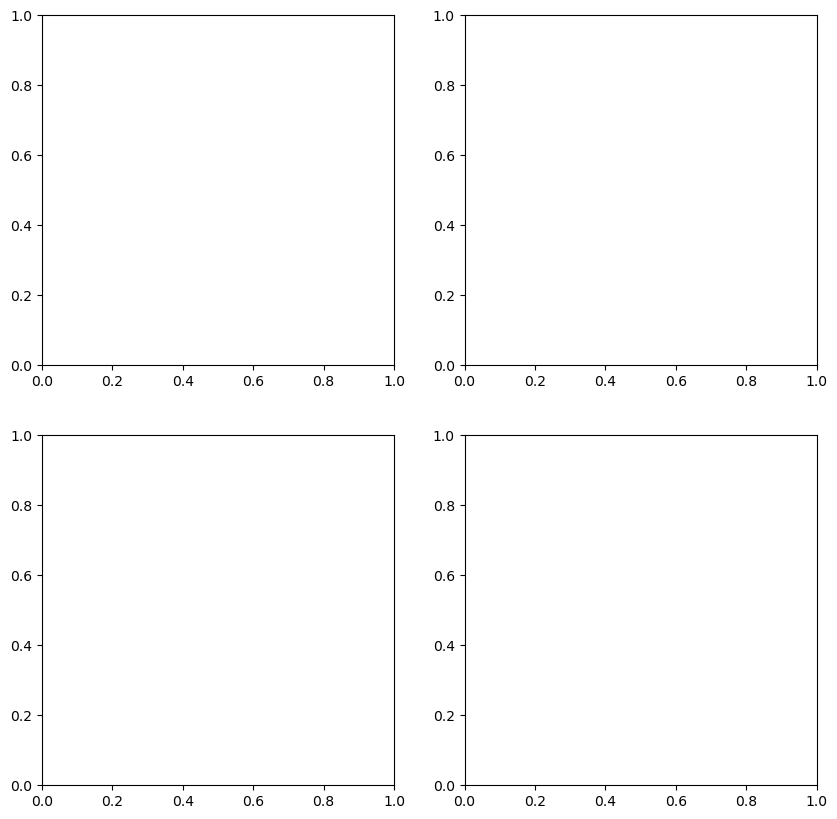

In [27]:
fig, axs = plt.subplots(2,2)

fig.set_size_inches(10,10)

sns.kdeplot(x=train_ab['0_shift_a'], y=train_ab['1_shift_a'], ax=axs[0,0], cmap="coolwarm")

stat = np.round(scipy.stats.spearmanr(train_ab.dropna()['0_shift_a'], train_ab.dropna()['1_shift_a']).statistic, 2)
p_val = np.round(scipy.stats.spearmanr(train_ab.dropna()['0_shift_a'], train_ab.dropna()['1_shift_a']).pvalue, 2)

axs[0,0].set_title(f'Spearman R is {stat} with p value {p_val}')
axs[0,0].set_ylabel('$a(t+1)$')
axs[0,0].set_xlabel('$a(t)$')

sns.kdeplot(x=train_ab['0_shift_a'], y=train_ab['1_shift_b'], ax=axs[0,1], cmap="coolwarm")

stat = np.round(scipy.stats.spearmanr(train_ab.dropna()['0_shift_a'], train_ab.dropna()['1_shift_b']).statistic, 2)
p_val = np.round(scipy.stats.spearmanr(train_ab.dropna()['0_shift_a'], train_ab.dropna()['1_shift_b']).pvalue, 2)

axs[0,1].set_title(f'Spearman R is {stat} with p value {p_val}')
axs[0,1].set_ylabel('$b(t+1)$')
axs[0,1].set_xlabel('$a(t)$')


sns.kdeplot(x=train_ab['0_shift_b'], y=train_ab['1_shift_a'], ax=axs[1,0], cmap="coolwarm")
,
stat = np.round(scipy.stats.spearmanr(train_ab.dropna()['0_shift_b'], train_ab.dropna()['1_shift_a']).statistic, 2)
p_val = np.round(scipy.stats.spearmanr(train_ab.dropna()['0_shift_b'], train_ab.dropna()['1_shift_a']).pvalue, 2)

axs[1,0].set_title(f'Spearman R is {stat} with p value {p_val}')
axs[1,0].set_ylabel('$a(t+1)$')
axs[1,0].set_xlabel('$b(t)$')


sns.kdeplot(x=train_ab['0_shift_b'], y=train_ab['1_shift_b'], ax=axs[1,1], cmap="coolwarm")

stat = np.round(scipy.stats.spearmanr(train_ab.dropna()['0_shift_b'], train_ab.dropna()['1_shift_b']).statistic, 2)
p_val = np.round(scipy.stats.spearmanr(train_ab.dropna()['0_shift_b'], train_ab.dropna()['1_shift_b']).pvalue, 2)

axs[1,1].set_title(f'Spearman R is {stat} with p value {p_val}')
axs[1,1].set_ylabel('$b(t+1)$')
axs[1,1].set_xlabel('$b(t)$')

axs[0,0].set_xlim(-5,5)
axs[0,0].set_ylim(-5,5)

axs[0,1].set_xlim(-5,5)
axs[0,1].set_ylim(-3,3)


axs[1,0].set_xlim(-3,3)
axs[1,0].set_ylim(-5,5)

axs[1,1].set_xlim(-3,3)
axs[1,1].set_ylim(-3,3)


#plt.savefig('Parameter_Distributions.pdf', bbox_inches = 'tight')


In [94]:
scipy.stats.pearsonr(train_ab.dropna()['0_shift_b'], train_ab.dropna()['1_shift_b'])

PearsonRResult(statistic=np.float64(0.39108952392301066), pvalue=np.float64(0.0))

In [95]:
train_ab = pd.concat([train_a, train_b], axis=1)
test_ab = pd.concat([test_a, test_b], axis=1)

train_ab['up_or_down'] = finished_up_train_df.shift(-5).values.flatten()
test_ab['up_or_down'] = finished_up_test_df.shift(-5).values.flatten()


In [96]:
scipy.stats.spearmanr(train_ab.dropna()['4_shift_a'], train_ab.dropna()['up_or_down'])

SignificanceResult(statistic=np.float64(0.050740289437842624), pvalue=np.float64(9.344063874606263e-117))

In [97]:
features = [f'{i}_shift_a' for i in range(5)] + [f'{i}_shift_b' for i in range(5)]
targets = ['5_shift_a', '5_shift_b']

In [98]:
import sklearn.linear_model

In [105]:
lr = sklearn.linear_model.Lasso(alpha=0.01)
train_ab_no_nans = train_ab.dropna()
test_ab_no_nans = test_ab.dropna()




lr.fit(train_ab_no_nans[features], train_ab_no_nans[targets[0]])
print(lr.score(train_ab_no_nans[features], train_ab_no_nans[targets[0]]))
print(lr.score(test_ab_no_nans[features], test_ab_no_nans[targets[0]]))

lr.fit(
    (train_ab_no_nans[features]),
    train_ab_no_nans[targets[1]]
)
print(
    lr.score(
        train_ab_no_nans[features], 
        train_ab_no_nans[targets[1]]
    )
)
print(
    lr.score(
        test_ab_no_nans[features], 
        test_ab_no_nans[targets[1]]
    )
)

0.005844841875322859
-0.01332670954330073
0.18210321745644642
0.23739293610986067


In [106]:
lr.coef_

array([ 1.21352153e-04,  1.28938904e-04,  0.00000000e+00, -0.00000000e+00,
        2.13980298e-04,  4.88819555e-02,  5.86194129e-02,  5.79455554e-02,
        1.00858281e-01,  2.95653645e-01])

<>:2: SyntaxWarning: invalid escape sequence '\h'
<>:2: SyntaxWarning: invalid escape sequence '\h'
/var/folders/t5/hglcpfcd3px36gr5wgd_4mtm0000gn/T/ipykernel_10403/1250736099.py:2: SyntaxWarning: invalid escape sequence '\h'
  plt.xlabel('$\hat{b}(t+1)$', fontsize=16)


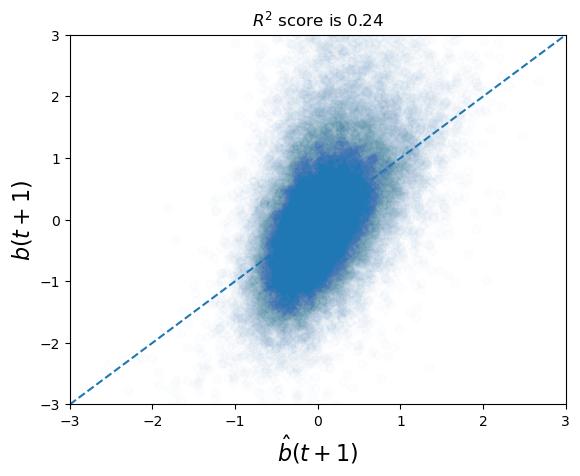

In [34]:
plt.scatter(lr.predict(test_ab_no_nans[features]), test_ab_no_nans[targets[1]], alpha=0.01)
plt.xlabel('$\hat{b}(t+1)$', fontsize=16)
plt.ylabel('$b(t+1)$', fontsize=16)

score = np.round(lr.score(test_ab_no_nans[features], test_ab_no_nans[targets[1]]), 2)
plt.title(f'$R^2$ score is {score}')
plt.xlim(-3,3)
plt.ylim(-3,3)
plt.plot([-3, 3], [-3, 3], '--')
#plt.savefig('Linear_scale_model.png', bbox_inches = 'tight')

<>:2: SyntaxWarning: invalid escape sequence '\h'
<>:2: SyntaxWarning: invalid escape sequence '\h'
/var/folders/t5/hglcpfcd3px36gr5wgd_4mtm0000gn/T/ipykernel_10403/2237961765.py:2: SyntaxWarning: invalid escape sequence '\h'
  plt.xlabel('$\hat{b}(t+1)$', fontsize=16)


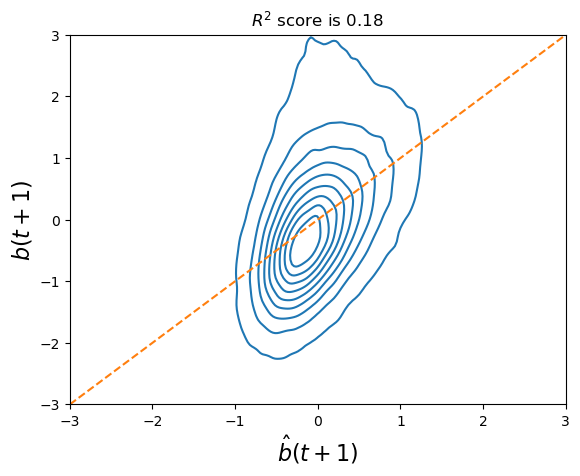

In [39]:
sns.kdeplot(x=lr.predict(train_ab_no_nans[features]), y=train_ab_no_nans[targets[1]])
plt.xlabel('$\hat{b}(t+1)$', fontsize=16)
plt.ylabel('$b(t+1)$', fontsize=16)

score = np.round(lr.score(train_ab_no_nans[features], train_ab_no_nans[targets[1]]), 2)
plt.title(f'$R^2$ score is {score}')
plt.xlim(-3,3)
plt.ylim(-3,3)
plt.plot([-3, 3], [-3, 3], '--')
#plt.savefig('Linear_scale_model.png', bbox_inches = 'tight')

In [45]:
scaled_a_train_df

,MMM,AOS,ABT,ABBV,ACN,ADBE,AMD,AES,AFL,A,...,WMB,WTW,WYNN,XEL,XYL,YUM,ZBRA,ZBH,ZTS,VIXY
2022-10-17,0.000000,0.000000,0.000000,0.859194,1.953435,0.000000,0.565539,0.000000,0.000000,0.877220,...,0.000000,-0.000144,0.000000,0.0,0.000000,0.000000,0.000000,1.138938,1.538531,0.0
2022-10-18,0.949676,0.000000,0.000000,0.859075,0.000000,0.000000,-0.349605,0.000000,0.000000,0.000000,...,0.000164,-0.000096,-3.270271,0.0,2.770485,1.167077,0.000000,0.894580,-1.126514,0.0
2022-10-19,0.939348,0.000099,-1.672254,0.823361,0.000000,0.899825,-0.658551,-0.000206,0.000166,1.788199,...,0.000161,0.000000,1.709822,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.0
2022-10-20,-0.472769,0.000000,0.000000,0.870464,0.000000,0.870337,0.485204,0.000000,-0.000085,1.779820,...,0.000000,-0.000121,3.329430,0.0,0.000000,0.000000,-0.000087,2.365479,-0.798219,0.0
2022-10-21,1.500732,0.000199,-3.439318,1.998595,-1.544177,0.655680,0.574034,0.000000,-0.000082,-1.782884,...,0.000000,0.000071,0.000000,0.0,2.755725,0.000000,0.000000,0.000000,-0.786777,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-06-24,0.000000,0.000000,-1.535397,-0.717100,0.000000,-0.511280,-0.477505,0.000000,0.000000,-0.837784,...,0.000116,0.000000,-2.103063,0.0,-5.559530,1.926861,0.000000,0.000000,-0.334878,0.0
2024-06-25,1.073818,0.000000,0.000000,-1.084375,-0.412002,-1.023416,0.379155,0.000000,0.000000,-1.687321,...,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,-0.342013,0.0
2024-06-26,-1.075513,0.000000,0.000000,-1.089899,1.350697,-0.765193,-0.709063,0.000000,0.000000,0.852130,...,-0.000090,0.000000,0.000000,0.0,1.896942,-0.977300,0.000000,-1.166293,-0.344826,0.0
2024-06-27,0.000000,0.000000,0.000000,0.735503,0.678548,1.480375,0.790614,0.000000,0.000000,0.000000,...,0.000000,0.000000,2.126408,0.0,0.000000,0.977596,0.000000,0.000000,0.000000,0.0


In [80]:
scipy.stats.spearmanr(
            scaled_b_train_df.shift(-1)['ABNB'].iloc[i:i+100], 
            scaled_b_train_df['ABNB'].iloc[i:i+100], 
        )

SignificanceResult(statistic=np.float64(0.31228322832283223), pvalue=np.float64(0.0015611483638221287))

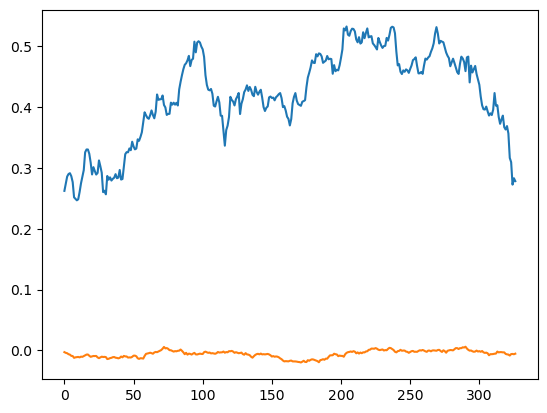

In [87]:
autocorrs = []

wrong_autocorrs = np.zeros((100, 327))
for i in range(327):
    autocorrs.append(
        scipy.stats.spearmanr(
            scaled_b_train_df.shift(-1)['MMM'].iloc[i:i+100], 
            scaled_b_train_df['MMM'].iloc[i:i+100], 
        ).statistic
    )

for r in range(100):
    scrambled_a = scaled_b_train_df['MMM'].sample(frac=1).reset_index()
    for i in range(327):
        
        wrong_autocorrs[r, i] = scipy.stats.spearmanr(
            scrambled_a.shift(-1)['MMM'].iloc[i:i+100], 
            scrambled_a['MMM'].iloc[i:i+100], 
        ).statistic
plt.plot(autocorrs)
plt.plot(np.mean(wrong_autocorrs, axis=0))

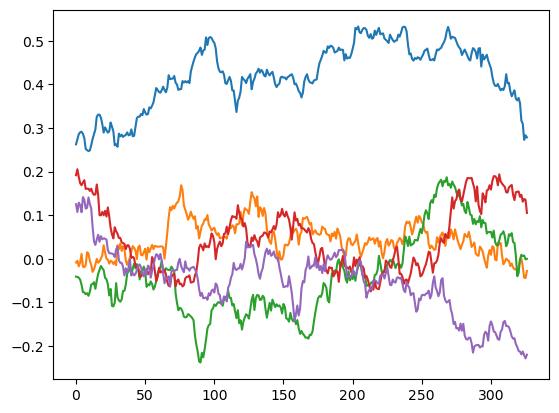

In [88]:
plt.plot(autocorrs)

plt.plot(wrong_autocorrs[0])
plt.plot(wrong_autocorrs[1])
plt.plot(wrong_autocorrs[2])
plt.plot(wrong_autocorrs[3])


In [66]:
from statsmodels.tsa.stattools import adfuller

result = adfuller(scaled_a_train_df['MMM'])
print(f'ADF Statistic: {result[0]}')
print(f'p-value: {result[1]}')

if result[1] > 0.05:
    print("The series is not stationary, differencing is required.")
else:
    print("The series is stationary.")

ADF Statistic: -4.090430630455869
p-value: 0.001004406818833354
The series is stationary.


In [93]:
from statsmodels.tsa.arima.model import ARIMA

model = ARIMA(scaled_b_train_df['MMM'], order=(2,0,2))  # Choose appropriate p, d, q
model_fit = model.fit()
print(model_fit.summary())

                               SARIMAX Results                                
Dep. Variable:                    MMM   No. Observations:                  427
Model:                 ARIMA(2, 0, 2)   Log Likelihood                -578.885
Date:                Wed, 23 Oct 2024   AIC                           1169.771
Time:                        22:17:20   BIC                           1194.111
Sample:                             0   HQIC                          1179.385
                                - 427                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const      -6.363e-05      0.101     -0.001      0.999      -0.199       0.199
ar.L1          0.1352      0.937      0.144      0.885      -1.702       1.972
ar.L2          0.1903      0.562      0.339      0.7

/Users/hiroku007/miniforge3/envs/algo_trading/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/Users/hiroku007/miniforge3/envs/algo_trading/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/Users/hiroku007/miniforge3/envs/algo_trading/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


In [90]:
import itertools
import statsmodels.api as sm

# Define the range of p, d, q values to try
p = d = q = range(0, 3)

# Create a list of all possible combinations of p, d, and q
pdq = list(itertools.product(p, d, q))

best_aic = float('inf')
best_order = None
best_model = None

for param in pdq:
    try:
        model = sm.tsa.ARIMA(scaled_b_train_df['MMM'], order=param)
        model_fit = model.fit()
        if model_fit.aic < best_aic:
            best_aic = model_fit.aic
            best_order = param
            best_model = model_fit
    except:
        continue

print(f'Best ARIMA Model: {best_order} with AIC {best_aic}')

/Users/hiroku007/miniforge3/envs/algo_trading/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/Users/hiroku007/miniforge3/envs/algo_trading/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/Users/hiroku007/miniforge3/envs/algo_trading/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/Users/hiroku007/miniforge3/envs/algo_trading/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has 

Best ARIMA Model: (2, 0, 0) with AIC 1165.8592642766657


/Users/hiroku007/miniforge3/envs/algo_trading/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/Users/hiroku007/miniforge3/envs/algo_trading/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/Users/hiroku007/miniforge3/envs/algo_trading/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/Users/hiroku007/miniforge3/envs/algo_trading/lib/python3.12/site-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible

In [91]:
n_test_observations = len(scaled_a_test_df)
predictions =  best_model.forecast(steps=n_test_observations)

/Users/hiroku007/miniforge3/envs/algo_trading/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:836: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/Users/hiroku007/miniforge3/envs/algo_trading/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:836: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


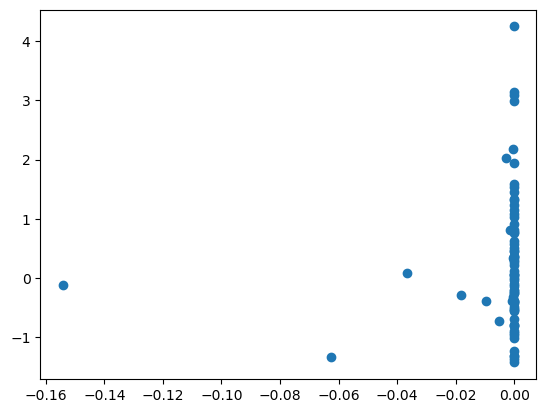

In [92]:
plt.scatter(predictions, scaled_b_test_df['MMM'])

In [42]:
np.corrcoef(lr.predict(train_ab_no_nans[features]), train_ab_no_nans[targets[1]] - lr.predict(train_ab_no_nans[features]))

array([[1.00000000e+00, 5.78895858e-16],
       [5.78895858e-16, 1.00000000e+00]])

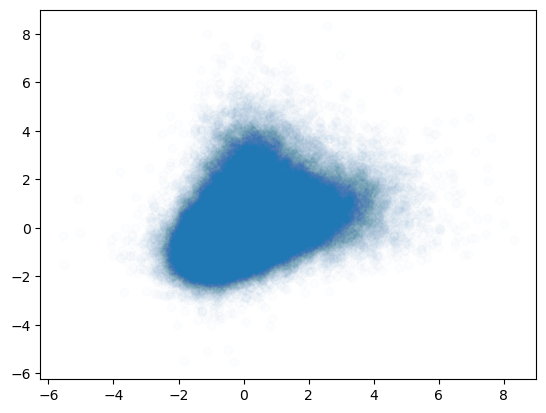

In [167]:
plt.scatter(train_b.dropna()['0_shift_b'], train_b.dropna()['1_shift_b'], alpha=0.01)

<Axes: xlabel='0_shift_b', ylabel='1_shift_b'>

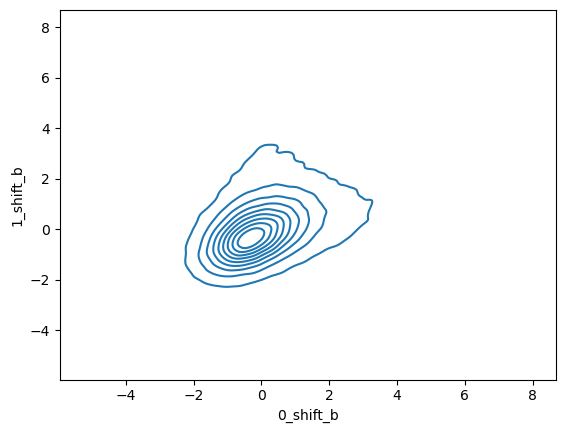

In [168]:
import seaborn

seaborn.kdeplot(x = train_b.dropna()['0_shift_b'], y = train_b.dropna()['1_shift_b'])

In [169]:
import xgboost

xgb_regressor = xgboost.XGBRegressor(n_estimators = 100, max_depth = 4, eta = 0.3)



xgb_regressor.fit(train_ab_no_nans[features], train_ab_no_nans[targets[1]])
print(xgb_regressor.score(train_ab_no_nans[features], train_ab_no_nans[targets[1]]))
print(xgb_regressor.score(test_ab_no_nans[features], test_ab_no_nans[targets[1]]))


0.21741223071192473
0.23537191057240525


<>:2: SyntaxWarning: invalid escape sequence '\h'
<>:2: SyntaxWarning: invalid escape sequence '\h'
/var/folders/t5/hglcpfcd3px36gr5wgd_4mtm0000gn/T/ipykernel_37583/2936747692.py:2: SyntaxWarning: invalid escape sequence '\h'
  plt.xlabel('$\hat{b}(t+1)$', fontsize=16)


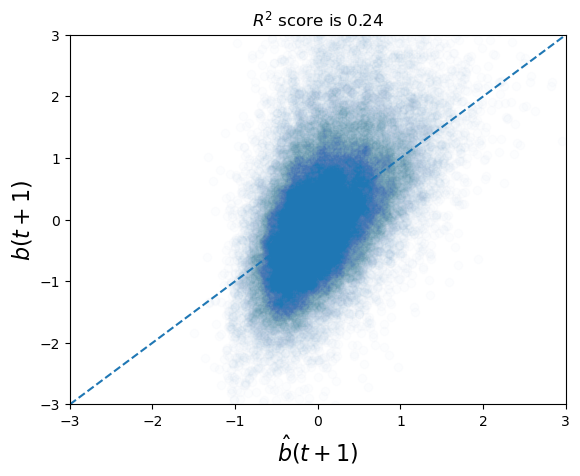

In [224]:
plt.scatter(xgb_regressor.predict(test_ab_no_nans[features]), test_ab_no_nans[targets[1]], alpha=0.01)
plt.xlabel('$\hat{b}(t+1)$', fontsize=16)
plt.ylabel('$b(t+1)$', fontsize=16)

score = np.round(xgb_regressor.score(test_ab_no_nans[features], test_ab_no_nans[targets[1]]), 2)
plt.title(f'$R^2$ score is {score}')
plt.xlim(-3,3)
plt.ylim(-3,3)
plt.plot([-3, 3], [-3, 3], '--')
plt.savefig('xgb_scale_model.png', bbox_inches = 'tight')

In [220]:
xgb_regressor.predict(test_ab_no_nans[features])

array([-0.21606153, -0.05376619, -0.395474  , ..., -0.56675005,
       -0.5080783 , -0.22278702], dtype=float32)

In [222]:
lr.predict(test_ab_no_nans[features])

array([-0.24074519, -0.15405532, -0.33938092, ..., -0.55045271,
       -0.46907881, -0.20853437])

In [170]:
import sklearn.ensemble

rf_regressor = sklearn.ensemble.RandomForestRegressor()

rf_regressor.fit(train_ab_no_nans[features], train_ab_no_nans[targets[1]])
print(rf_regressor.score(train_ab_no_nans[features], train_ab_no_nans[targets[1]]))
print(rf_regressor.score(test_ab_no_nans[features], test_ab_no_nans[targets[1]]))



0.8838482045795175
0.2158773782383654


In [171]:
import sklearn.ensemble

xg_rf_regressor = xgboost.XGBRFRegressor()

xg_rf_regressor.fit(train_ab_no_nans[features], train_ab_no_nans[targets[1]])
print(xg_rf_regressor.score(train_ab_no_nans[features], train_ab_no_nans[targets[1]]))
print(xg_rf_regressor.score(test_ab_no_nans[features], test_ab_no_nans[targets[1]]))

0.19475778871916372
0.23119117100254805


In [172]:
import sklearn.ensemble

xg_rf_regressor = xgboost.XGBRFRegressor()

xg_rf_regressor.fit(train_ab_no_nans[features], train_ab_no_nans[targets[0]])
print(xg_rf_regressor.score(train_ab_no_nans[features], train_ab_no_nans[targets[0]]))
print(xg_rf_regressor.score(test_ab_no_nans[features], test_ab_no_nans[targets[0]]))

0.010415414614202811
0.0016629019795278976


In [173]:
import sklearn.ensemble

xg_regressor = xgboost.XGBRegressor(n_estimators = 100, max_depth = 6, eta=0.3, reg_lambda=1, objective="reg:pseudohubererror")

xg_regressor.fit(train_ab_no_nans[features], train_ab_no_nans[targets[0]])
print(xg_regressor.score(train_ab_no_nans[features], train_ab_no_nans[targets[0]]))
print(xg_regressor.score(test_ab_no_nans[features], test_ab_no_nans[targets[0]]))

0.06791109248691485
-0.014827984475756839


In [247]:
xgb_classifier = xgboost.XGBClassifier(n_estimators = 100, max_depth = 6)



xgb_classifier.fit(train_ab_no_nans[features], train_ab_no_nans['up_or_down']>0)
print(xgb_classifier.score(train_ab_no_nans[features], train_ab_no_nans['up_or_down']>0))
print(xgb_classifier.score(test_ab_no_nans[features], test_ab_no_nans['up_or_down']>0))


0.6274979234865882
0.507784252203795


In [248]:
from sklearn.metrics  import classification_report

print(
    classification_report(
        y_pred=xgb_classifier.predict(test_ab_no_nans[features]),
        y_true=test_ab_no_nans['up_or_down']>0
    )
)

              precision    recall  f1-score   support

       False       0.52      0.57      0.55     17378
        True       0.49      0.44      0.46     16087

    accuracy                           0.51     33465
   macro avg       0.51      0.51      0.50     33465
weighted avg       0.51      0.51      0.51     33465



In [243]:
np.sum(test_ab_no_nans['up_or_down']>0)/len(test_ab_no_nans)

np.float64(0.4807111907963544)

In [235]:
from sklearn.linear_model import LogisticRegression

logistic_regressor = LogisticRegression()
logistic_regressor.fit(train_ab_no_nans[features], train_ab_no_nans['up_or_down']>0)
print(logistic_regressor.score(train_ab_no_nans[features], train_ab_no_nans['up_or_down']>0))
print(logistic_regressor.score(test_ab_no_nans[features], test_ab_no_nans['up_or_down']>0))


0.5214393902379441
0.5192888092036456


In [236]:
probabilities = xgb_classifier.predict_proba(train_ab_no_nans[features])[:,1]

In [194]:
train_ab_no_nans.columns

Index(['0_shift_a', '1_shift_a', '2_shift_a', '3_shift_a', '4_shift_a',
       '5_shift_a', '0_shift_b', '1_shift_b', '2_shift_b', '3_shift_b',
       '4_shift_b', '5_shift_b', 'up_or_down'],
      dtype='object')

In [195]:
scipy.stats.spearmanr(train_ab_no_nans[targets[0]]>0, train_ab_no_nans['up_or_down']>0)

SignificanceResult(statistic=np.float64(0.2527402568136292), pvalue=np.float64(0.0))

In [196]:
scipy.stats.spearmanr(test_ab_no_nans[targets[0]]>0, test_ab_no_nans['up_or_down']>0)

SignificanceResult(statistic=np.float64(0.21440471226550356), pvalue=np.float64(0.0))

In [197]:
linear_regressor = sklearn.linear_model.LinearRegression()

linear_regressor.fit(xgb_classifier.predict_proba(train_ab_no_nans[features]), train_ab_no_nans[targets[0]])
print(linear_regressor.score(xgb_classifier.predict_proba(train_ab_no_nans[features]), train_ab_no_nans[targets[0]]))
print(linear_regressor.score(xgb_classifier.predict_proba(test_ab_no_nans[features]), test_ab_no_nans[targets[0]]))


0.00454449504302612
0.0006134872413198211


In [198]:
np.std(train_ab_no_nans[targets[0]].values[probabilities<0.6])

np.float64(1.0004011850425039)

In [199]:
scipy.stats.spearmanr(probabilities, train_ab_no_nans[targets[0]])

SignificanceResult(statistic=np.float64(0.2617826338399215), pvalue=np.float64(0.0))

0.49120258083092794
0.508188181142009


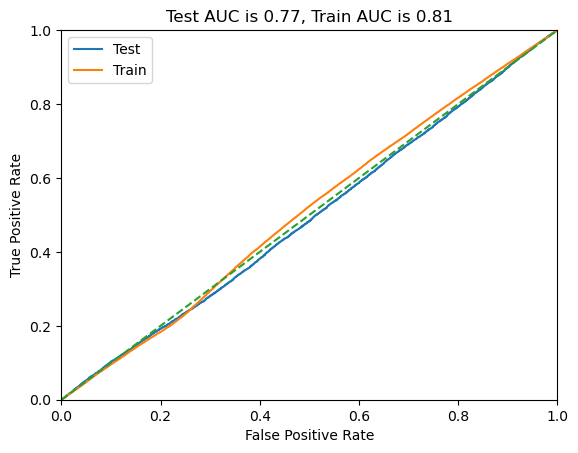

In [244]:
fpr, tpr, _ = sklearn.metrics.roc_curve(test_ab_no_nans['up_or_down']>0, xgb_classifier.predict_proba(test_ab_no_nans[features])[:,1])
plt.plot(fpr, tpr, label = 'Test')
print(sklearn.metrics.auc(fpr, tpr))
fpr, tpr, _ = sklearn.metrics.roc_curve(train_ab_no_nans['up_or_down']>0, xgb_classifier.predict_proba(train_ab_no_nans[features])[:,1])
print(sklearn.metrics.auc(fpr, tpr))
plt.plot(fpr, tpr,  label = 'Train')
plt.plot([0, 1], [0, 1], ls = '--')
plt.xlim((0,1))
plt.ylim((0,1))
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Test AUC is 0.77, Train AUC is 0.81')
plt.legend(loc = 'best')
#plt.savefig('auc_roc.pdf', bbox_inches = 'tight')

In [231]:
sum(test_ab_no_nans[targets[0]]>0)/len(test_ab_no_nans)

0.37176154190945765

0.7207816815054253
0.7523977098134811


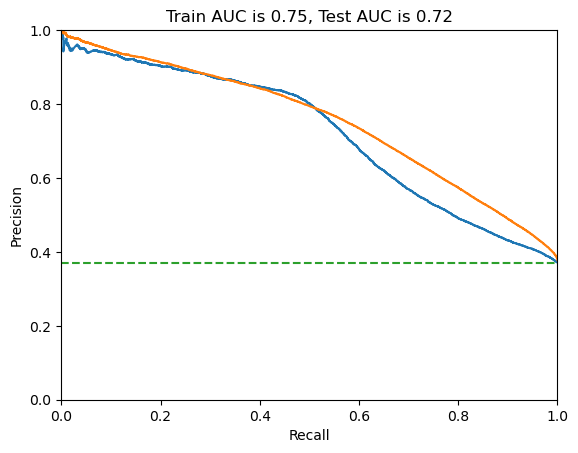

In [234]:
precision, recall, _ = sklearn.metrics.precision_recall_curve(test_ab_no_nans[targets[0]]>0, xgb_classifier.predict_proba(test_ab_no_nans[features])[:,1])
plt.plot(recall, precision)
print(sklearn.metrics.auc(recall, precision))
precision, recall, _ = sklearn.metrics.precision_recall_curve(train_ab_no_nans[targets[0]]>0, xgb_classifier.predict_proba(train_ab_no_nans[features])[:,1])
print(sklearn.metrics.auc(recall, precision))
plt.plot(recall, precision)
plt.plot([0, 1], [0.37, 0.37], ls = '--')
plt.xlim((0,1))
plt.ylim((0,1))
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Train AUC is 0.75, Test AUC is 0.72')
plt.savefig('prc.pdf', bbox_inches = 'tight')

0.626499079252864
0.6159960376355325


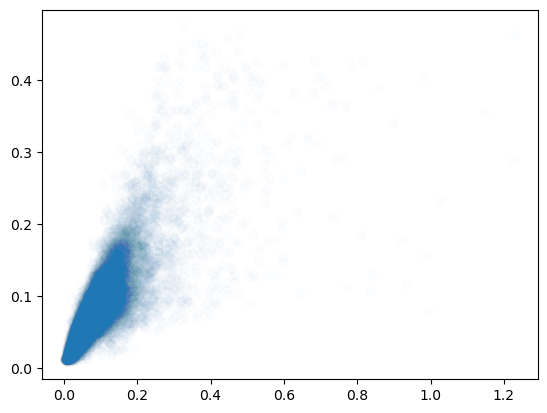

In [115]:
xgb_regressor = xgboost.XGBRegressor(n_estimators = 100, max_depth = 5, objective='reg:absoluteerror')



xgb_regressor.fit(train_ab_no_nans[features], train_ab_no_nans[targets[1]])
print(xgb_regressor.score(train_ab_no_nans[features], train_ab_no_nans[targets[1]]))
print(xgb_regressor.score(test_ab_no_nans[features], test_ab_no_nans[targets[1]]))

plt.scatter(test_ab_no_nans[targets[1]], xgb_regressor.predict(test_ab_no_nans[features]), alpha=0.01)

0.014761125629051297
-0.006138313414774332


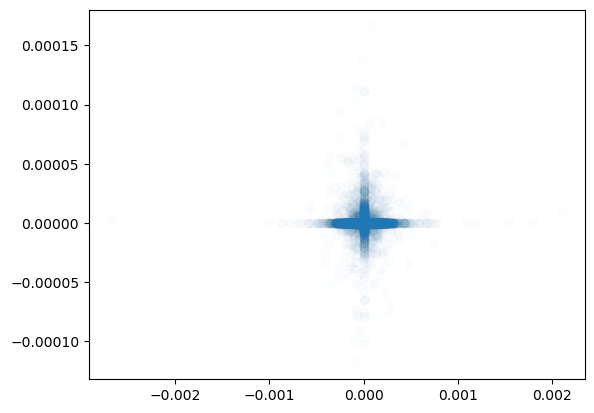

In [117]:
xgb_regressor = xgboost.XGBRegressor(n_estimators = 100, max_depth = 7, objective='reg:absoluteerror')



xgb_regressor.fit(train_ab_no_nans[features], train_ab_no_nans[targets[0]])
print(xgb_regressor.score(train_ab_no_nans[features], train_ab_no_nans[targets[0]]))
print(xgb_regressor.score(test_ab_no_nans[features], test_ab_no_nans[targets[0]]))

plt.scatter(test_ab_no_nans[targets[0]], xgb_regressor.predict(test_ab_no_nans[features]), alpha=0.01)

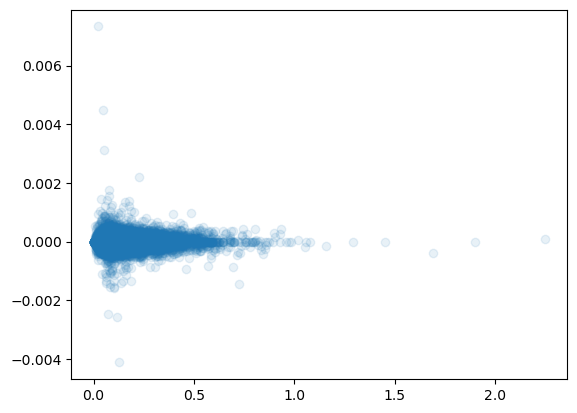

In [158]:
plt.scatter(train_ab['0_shift_b'], train_ab['1_shift_a'], alpha=0.1)


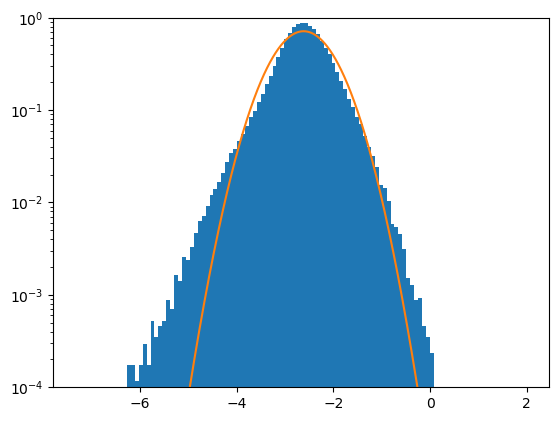

In [177]:
plt.hist(np.log(train_ab['0_shift_b']), bins=100, density = True)
x = np.arange(-7, 2, 0.001)

mu = np.mean(np.log(train_ab['0_shift_b']))
std = np.std(np.log(train_ab['0_shift_b']))

y = 1./np.sqrt(2*np.pi*std**2) * np.exp(-(x - mu)**2/(2*std**2))

plt.yscale('log')
plt.ylim((10**-4, 10**0))
plt.plot(x,y)
plt.show()

In [160]:
scipy.stats.pearsonr(train_ab_no_nans['0_shift_b'], train_ab_no_nans['1_shift_a'])

PearsonRResult(statistic=np.float64(0.014196732284662578), pvalue=np.float64(9.114557599563118e-11))

In [163]:
train_ab_no_nans[features].corr()

,0_shift_a,1_shift_a,2_shift_a,3_shift_a,4_shift_a,0_shift_b,1_shift_b,2_shift_b,3_shift_b,4_shift_b
0_shift_a,1.000000,0.046113,0.020614,0.010958,0.014031,-0.113859,0.007869,0.007222,0.011892,0.009308
1_shift_a,0.046113,1.000000,0.046117,0.020679,0.010943,0.014197,-0.114375,0.007063,0.006369,0.011305
2_shift_a,0.020614,0.046117,1.000000,0.046096,0.020715,0.017060,0.014549,-0.114111,0.007415,0.006694
3_shift_a,0.010958,0.020679,0.046096,1.000000,0.045755,0.015433,0.016922,0.014281,-0.114297,0.007480
4_shift_a,0.014031,0.010943,0.020715,0.045755,1.000000,0.008695,0.015963,0.017534,0.014800,-0.113435
0_shift_b,-0.113859,0.014197,0.017060,0.015433,0.008695,1.000000,0.761045,0.667887,0.626776,0.611381
1_shift_b,0.007869,-0.114375,0.014549,0.016922,0.015963,0.761045,1.000000,0.760864,0.667716,0.626487
2_shift_b,0.007222,0.007063,-0.114111,0.014281,0.017534,0.667887,0.760864,1.000000,0.760475,0.667057
3_shift_b,0.011892,0.006369,0.007415,-0.114297,0.014800,0.626776,0.667716,0.760475,1.000000,0.760111
4_shift_b,0.009308,0.011305,0.006694,0.007480,-0.113435,0.611381,0.626487,0.667057,0.760111,1.000000


In [154]:
from sklearn.linear_model import HuberRegressor

huber = sklearn.linear_model.LinearRegression()
huber.fit(train_ab_no_nans[features], train_ab_no_nans[targets[0]])
print(huber.score(train_ab_no_nans[features], train_ab_no_nans[targets[0]]))
print(huber.score(test_ab_no_nans[features], test_ab_no_nans[targets[0]]))



0.0031470743801716994
-0.00033677607005211385


In [155]:
huber.coef_

array([ 2.48199814e-03,  1.00352084e-02,  9.46565274e-03,  1.88327439e-02,
        4.56495342e-02,  1.17267774e-05, -2.70897821e-05,  1.15067764e-05,
        1.29213895e-05,  1.84064344e-05])

In [102]:
train_ab_no_nans[targets[0]]>0

0         False
1         False
2          True
3          True
4         False
          ...  
212683    False
212684    False
212685    False
212686    False
212687    False
Name: 5_shift_a, Length: 208383, dtype: bool

In [40]:
import xgboost

xgb_regressor = xgboost.XGBRegressor()
train_a_no_nans = train_a.dropna()
test_a_no_nans = test_a.dropna()


xgb_regressor.fit(train_a_no_nans[['0 shift', '1 shift', '2 shift', '3 shift', '4 shift']], train_a_no_nans[['5 shift']])
print(xgb_regressor.score(train_a_no_nans[['0 shift', '1 shift', '2 shift', '3 shift', '4 shift']], train_a_no_nans[['5 shift']]))
print(xgb_regressor.score(test_a_no_nans[['0 shift', '1 shift', '2 shift', '3 shift', '4 shift']], test_a_no_nans[['5 shift']]))


KeyError: "None of [Index(['0 shift', '1 shift', '2 shift', '3 shift', '4 shift'], dtype='object')] are in the [columns]"

In [ ]:
one_shifted = a_params_train_df.shift(-1)
one_shifted.columns = [f'{col_name}_shift1' for col_name in a_params_train_df.columns]
one_shifted = pd.DataFrame(one_shifted.values.flatten())

two_shifted = a_params_train_df.shift(-2)
two_shifted.columns = [f'{col_name}_shift2' for col_name in a_params_train_df.columns]
two_shifted = pd.DataFrame(two_shifted.values.flatten())

three_shifted = a_params_train_df.shift(-3)
three_shifted.columns = [f'{col_name}_shift3' for col_name in a_params_train_df.columns]
three_shifted = pd.DataFrame(three_shifted.values.flatten())

four_shifted = a_params_train_df.shift(-4)
four_shifted.columns = [f'{col_name}_shift4' for col_name in a_params_train_df.columns]
four_shifted = pd.DataFrame(four_shifted.values.flatten())

five_shifted = a_params_train_df.shift(-5)
five_shifted.columns = [f'{col_name}_shift5' for col_name in a_params_train_df.columns]
five_shifted = pd.DataFrame(five_shifted.values.flatten())

collapsed_df = pd.DataFrame(a_params_train_df.values.flatten())

train_a = pd.concat([collapsed_df, one_shifted, two_shifted, three_shifted, four_shifted, five_shifted], axis=1)



one_shifted = a_params_test_df.shift(-1)
one_shifted.columns = [f'{col_name}_shift1' for col_name in a_params_test_df.columns]
one_shifted = pd.DataFrame(one_shifted.values.flatten())

two_shifted = a_params_test_df.shift(-2)
two_shifted.columns = [f'{col_name}_shift2' for col_name in a_params_test_df.columns]
two_shifted = pd.DataFrame(two_shifted.values.flatten())

three_shifted = a_params_test_df.shift(-3)
three_shifted.columns = [f'{col_name}_shift3' for col_name in a_params_test_df.columns]
three_shifted = pd.DataFrame(three_shifted.values.flatten())

four_shifted = a_params_test_df.shift(-4)
four_shifted.columns = [f'{col_name}_shift4' for col_name in a_params_test_df.columns]
four_shifted = pd.DataFrame(four_shifted.values.flatten())

five_shifted = a_params_test_df.shift(-5)
five_shifted.columns = [f'{col_name}_shift5' for col_name in a_params_test_df.columns]
five_shifted = pd.DataFrame(five_shifted.values.flatten())

collapsed_df = pd.DataFrame(a_params_test_df.values.flatten())

test_a = pd.concat([collapsed_df, one_shifted, two_shifted, three_shifted, four_shifted, five_shifted], axis=1)